# 05 — Scoring a Long Sequence with gkmSVM

**Vignette index:** | [`01` GKMKernel basics](01_basic_kernel_matrix.ipynb) | [`02` Distance metrics & kernels](02_distance_metrics_and_kernels.ipynb) | [`03` SVM with kernel](03_svc_with_kernel.ipynb) | [`04` Clustering](04_clustering_sequences.ipynb) | `**05**` Long sequence scoring | [`06` Weighted (WGKM) kernel](06_weighted_kernel.ipynb) | [`07` Transforms & comparison](07_transform_and_comparison.ipynb) | [`08` Windowed 3D tensors](08_windowed_3d_tensors.ipynb) | [`09` Spectrum encoder & NB](09_spectrum_encoder_and_differential.ipynb) | [`10` Gappy encoder](10_gappy_encoder.ipynb) | [`11` Mismatch encoder](11_mismatch_encoder.ipynb) | [`12` Shuffler & chunker](12_shuffler_and_chunker.ipynb)

Train a `KernelSVM` on short sequences, then scan a long sequence using the gkm kernel's `sliding_window_query_kernel` to find where the TF-binding signal is strongest.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from kmer.kernels import GKMKernel
from kmer.models import KernelSVM

np.random.seed(0)
def random_seq(n, rng):
    return "".join(rng.choice(list("ACGT"), size=n))
rng = np.random.default_rng(0)

positives = ["ACGTACGT" + random_seq(12, rng) for _ in range(40)]
negatives = [random_seq(20, rng) for _ in range(40)]
seqs_train = positives + negatives
y_train = np.array([1]*40 + [0]*40)

kern = GKMKernel(L=10, k=6, d=3, kernel_type="truncated", use_rc=True)
clf = KernelSVM(kern, C=1.0)
clf.fit(seqs_train, y_train)
print("Trained.")

Trained.


## Build a long sequence with a motif at position 150

In [2]:
LONG_LEN = 300
MOTIF_POS = 150
rng2 = np.random.default_rng(99)
long_seq = list(random_seq(LONG_LEN, rng2))
for i, c in enumerate("ACGTACGTACGT"):
    long_seq[MOTIF_POS + i] = c
long_seq = "".join(long_seq)
print(f"Long sequence length: {len(long_seq)}")

Long sequence length: 300


## Score the long sequence with a sliding window

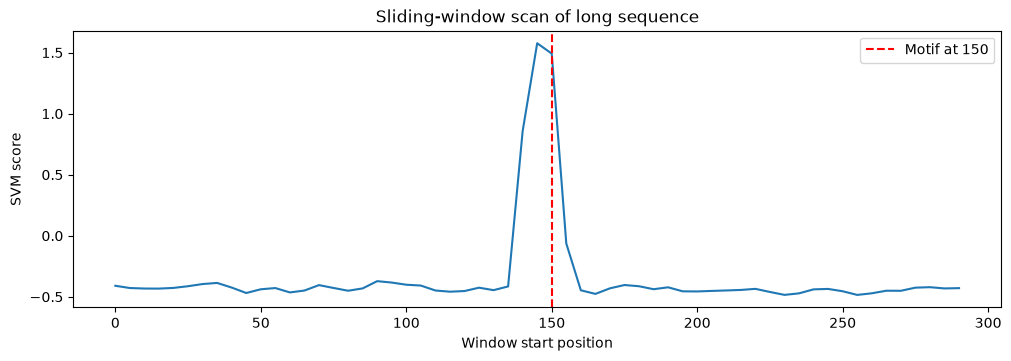

Peak at position 145 (motif at 150)


In [3]:
sv_indices = clf._svc_.support_
sv_seqs = [clf._train_seqs_[i] for i in sv_indices]
sv_coef = clf._svc_.dual_coef_[0]
intercept = clf._svc_.intercept_[0]

kern_scan = GKMKernel(L=10, k=6, d=3, kernel_type="truncated", use_rc=True)
kern_scan.set_references(sv_seqs)

WINDOW = 20
SHIFT = 5
W = kern_scan.sliding_window_query_kernel([long_seq], window=WINDOW, shift=SHIFT)
K_windows = np.asarray(W[0])

scores = K_windows @ sv_coef + intercept

window_starts = np.arange(len(scores)) * SHIFT
fig, ax = plt.subplots(figsize=(10, 3.5), constrained_layout=True)
ax.plot(window_starts, scores, "-")
ax.axvline(MOTIF_POS, color="r", linestyle="--", label=f"Motif at {MOTIF_POS}")
ax.set_xlabel("Window start position")
ax.set_ylabel("SVM score")
ax.set_title("Sliding-window scan of long sequence")
ax.legend()
plt.show()

peak_pos = window_starts[np.argmax(scores)]
print(f"Peak at position {peak_pos} (motif at {MOTIF_POS})")